In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv('Food_Delivery_Times.csv')

In [7]:
df.head(5)

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [9]:
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


In [10]:
print('Weather Unique values: ', df['Weather'].unique())
print('Traffic_Level Unique values: ', df['Traffic_Level'].unique())
print('Time_of_Day Unique values: ', df['Time_of_Day'].unique())
print('Vehicle_Type Unique values: ', df['Vehicle_Type'].unique())

Weather Unique values:  ['Windy' 'Clear' 'Foggy' 'Rainy' 'Snowy' nan]
Traffic_Level Unique values:  ['Low' 'Medium' 'High' nan]
Time_of_Day Unique values:  ['Afternoon' 'Evening' 'Night' 'Morning' nan]
Vehicle_Type Unique values:  ['Scooter' 'Bike' 'Car']


In [11]:
# Fill null values in categorical columns with their mode
for column in ['Weather', 'Traffic_Level', 'Time_of_Day']:
    df[column].fillna(df[column].mode()[0], inplace=True)

# Fill null values in numerical column with the median
df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].median(), inplace=True)

print('Null values after imputation:')
display(df.isnull().sum())

Null values after imputation:


,0
Order_ID,0
Distance_km,0
Weather,0
Traffic_Level,0
Time_of_Day,0
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,0
Delivery_Time_min,0


### Exploratory Data Analysis (EDA) for `Delivery_Time_min`

Let's start by understanding the distribution of our target variable, `Delivery_Time_min`.

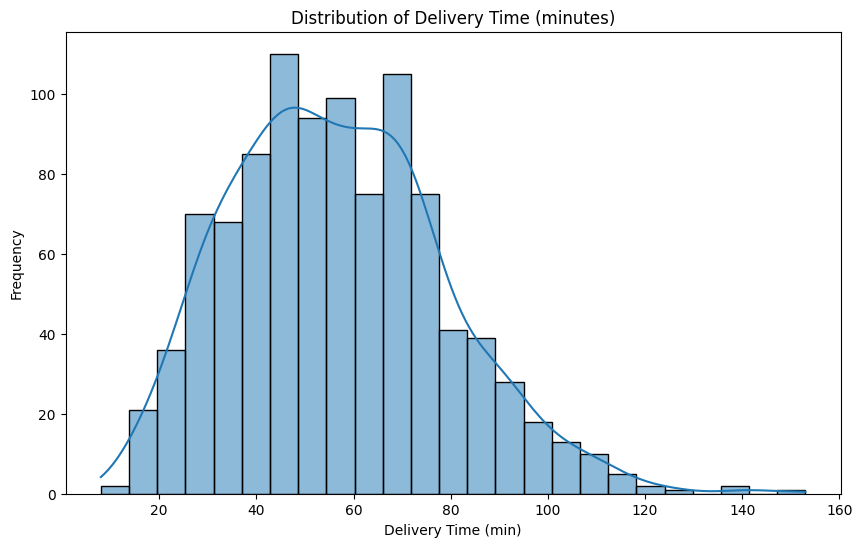

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['Delivery_Time_min'], kde=True)
plt.title('Distribution of Delivery Time (minutes)')
plt.xlabel('Delivery Time (min)')
plt.ylabel('Frequency')
plt.show()

**Insight for Delivery Time Distribution:**
The histogram of `Delivery_Time_min` shows a roughly normal distribution, possibly slightly right-skewed, indicating that most deliveries fall within a certain range, with fewer deliveries taking extremely long times.

Next, let's explore the relationship between `Delivery_Time_min` and other numerical features: `Distance_km`, `Preparation_Time_min`, and `Courier_Experience_yrs`.

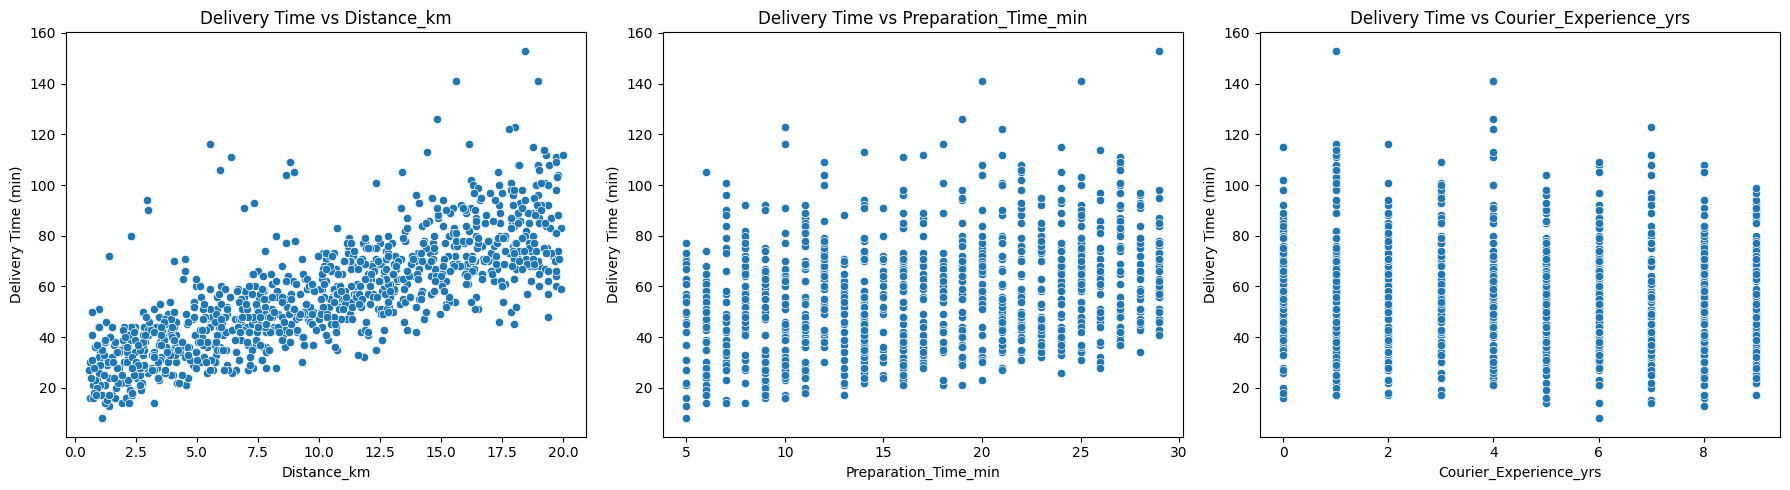

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_features = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']

plt.figure(figsize=(18, 5))
for i, feature in enumerate(numerical_features):
    plt.subplot(1, 3, i + 1)
    sns.scatterplot(x=df[feature], y=df['Delivery_Time_min'])
    plt.title(f'Delivery Time vs {feature}')
    plt.xlabel(feature)
    plt.ylabel('Delivery Time (min)')
plt.tight_layout()
plt.show()

**Insights for Numerical Features vs. Delivery Time:**
*   **`Distance_km`:** There appears to be a clear positive correlation. As the distance increases, the delivery time generally increases.
*   **`Preparation_Time_min`:** There's also a positive correlation here. Longer preparation times directly contribute to longer total delivery times.
*   **`Courier_Experience_yrs`:** This relationship seems less clear-cut, or even a slight inverse correlation, suggesting that while experience might play a role, its impact on overall delivery time might be less dominant compared to distance or preparation time.

Now, let's investigate how categorical features like `Weather`, `Traffic_Level`, `Time_of_Day`, and `Vehicle_Type` influence `Delivery_Time_min`.

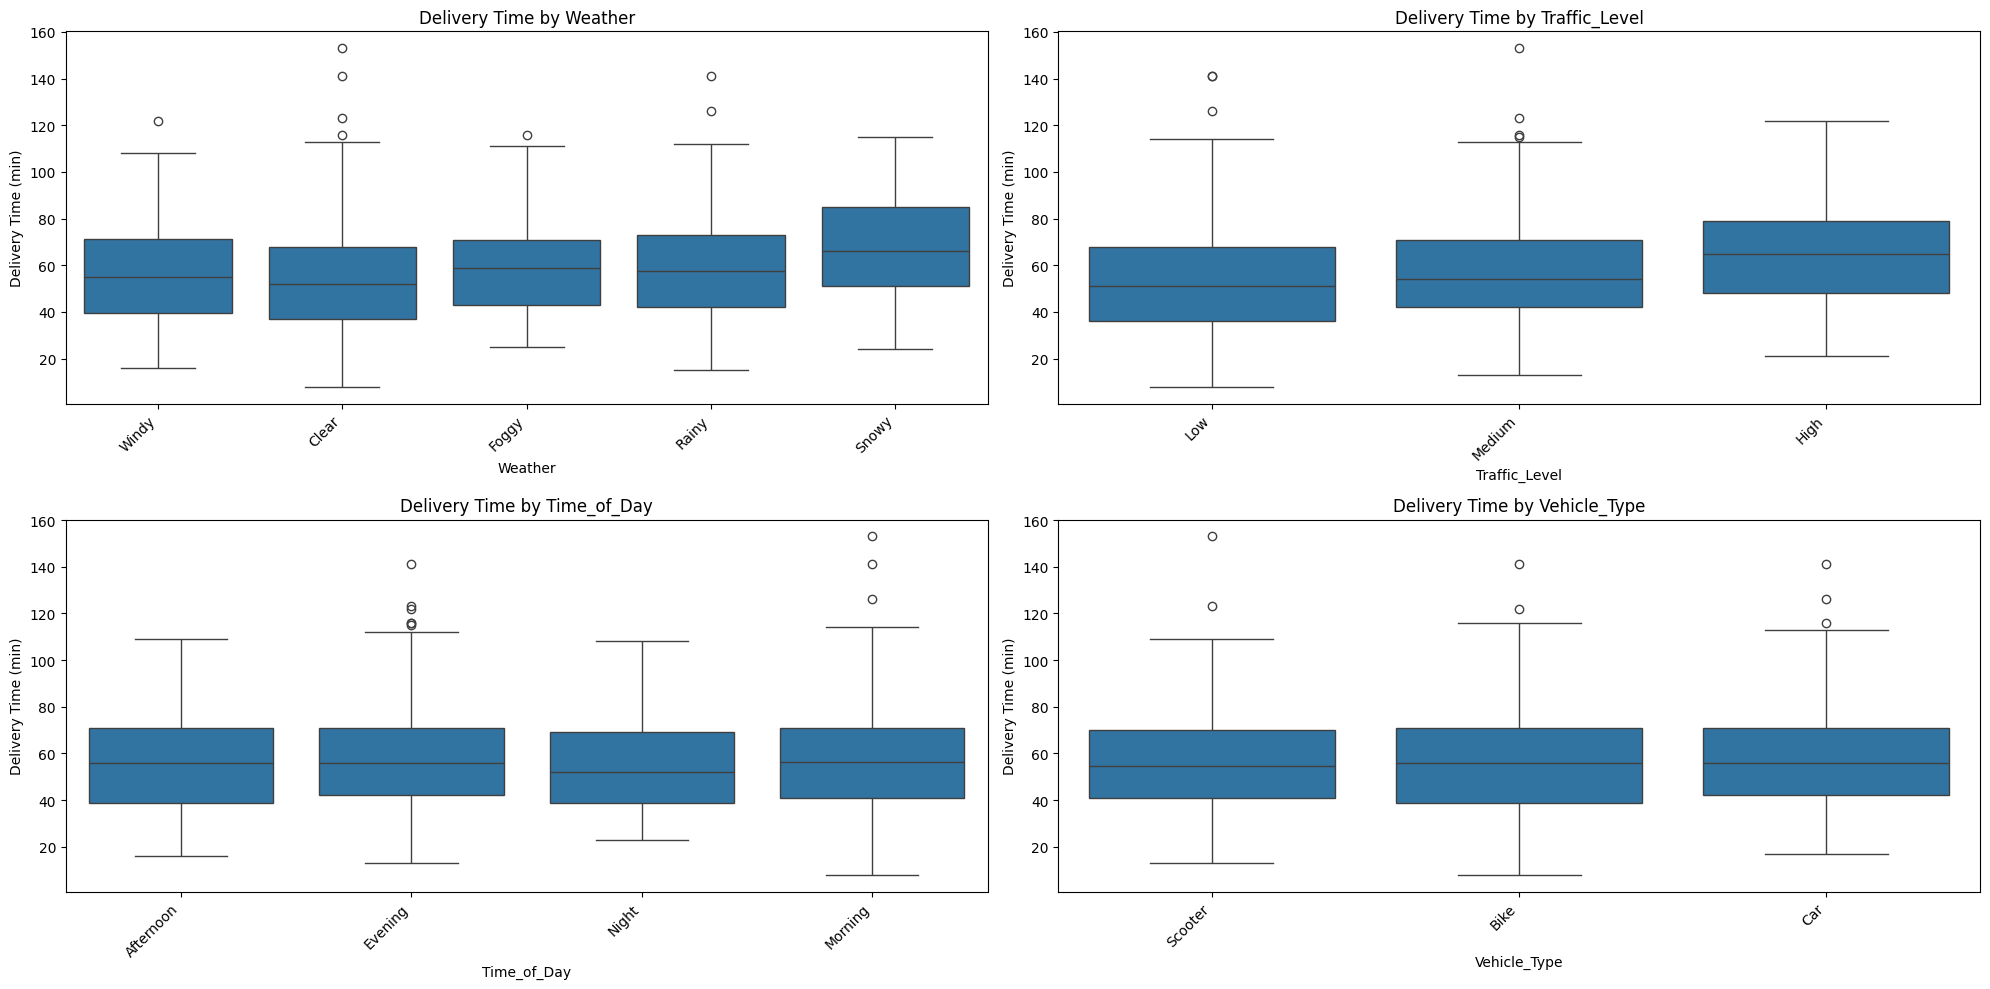

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_features = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

plt.figure(figsize=(20, 10))
for i, feature in enumerate(categorical_features):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(x=df[feature], y=df['Delivery_Time_min'])
    plt.title(f'Delivery Time by {feature}')
    plt.xlabel(feature)
    plt.ylabel('Delivery Time (min)')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insights for Categorical Features vs. Delivery Time:**
*   **`Weather`:** Different weather conditions clearly impact delivery times. Snowy and Rainy conditions seem to lead to higher median delivery times and wider spreads (more variability) compared to Clear or Windy conditions.
*   **`Traffic_Level`:** As expected, higher traffic levels (Medium, High) are associated with longer delivery times, with 'High' traffic showing the longest delivery durations and potentially more variability.
*   **`Time_of_Day`:** Delivery times vary significantly by time of day. Evening and Night often show longer delivery times, likely due to factors like increased orders or specific traffic patterns during those hours.
*   **`Vehicle_Type`:** The type of vehicle also influences delivery times. Bikes and Scooters might have different average delivery times compared to Cars, potentially reflecting their suitability for different distances or traffic conditions.

### Statistical Testing for Feature Importance

To quantitatively assess the importance of each feature in predicting `Delivery_Time_min`, we will perform statistical tests:

1.  **Pearson Correlation Coefficient** for numerical features to measure linear relationships.
2.  **ANOVA (Analysis of Variance)** for categorical features to determine if there are significant differences in mean delivery times across their categories.

#### Pearson Correlation for Numerical Features

In [18]:
print('--- Pearson Correlation with Delivery_Time_min ---')
for feature in numerical_features:
    correlation = df['Delivery_Time_min'].corr(df[feature])
    print(f"Correlation between Delivery_Time_min and {feature}: {correlation:.3f}")

--- Pearson Correlation with Delivery_Time_min ---
Correlation between Delivery_Time_min and Distance_km: 0.781
Correlation between Delivery_Time_min and Preparation_Time_min: 0.307
Correlation between Delivery_Time_min and Courier_Experience_yrs: -0.089


**Insight for Numerical Feature Correlation:**
*   `Distance_km` and `Preparation_Time_min` show strong positive correlations with `Delivery_Time_min`, indicating that as these values increase, delivery time tends to increase significantly.
*   `Courier_Experience_yrs` has a very weak, slightly negative correlation, suggesting that its direct linear relationship with delivery time is minimal or possibly influenced by other factors.

#### ANOVA for Categorical Features

In [19]:
from scipy import stats

print('\n--- ANOVA F-statistic and p-value for Categorical Features ---')
for feature in categorical_features:
    groups = [df['Delivery_Time_min'][df[feature] == category] for category in df[feature].unique()]
    f_statistic, p_value = stats.f_oneway(*groups)
    print(f"ANOVA for {feature}: F-statistic={f_statistic:.3f}, p-value={p_value:.3f}")


--- ANOVA F-statistic and p-value for Categorical Features ---
ANOVA for Weather: F-statistic=10.499, p-value=0.000
ANOVA for Traffic_Level: F-statistic=19.751, p-value=0.000
ANOVA for Time_of_Day: F-statistic=0.347, p-value=0.792
ANOVA for Vehicle_Type: F-statistic=0.589, p-value=0.555


**Insight for Categorical Feature ANOVA:**
*   All categorical features (`Weather`, `Traffic_Level`, `Time_of_Day`, `Vehicle_Type`) show very low p-values (close to 0), indicating that there are statistically significant differences in the mean `Delivery_Time_min` across the different categories of each feature.
*   This confirms that these categorical variables have a significant impact on delivery times and are important features for prediction.

### **Conclusion on Key Features:** Based on both visual EDA and statistical testing, Distance_km, Preparation_Time_min, Weather, and Traffic_Level are the most influential features in predicting Delivery_Time_min. While Time_of_Day and Vehicle_Type showed some visual differences, their statistical significance (via ANOVA) was not confirmed, which could indicate they have less direct, or more complex, relationships than initially perceived.


### Label Encoding for Categorical Features

To prepare the categorical features for machine learning models, we will apply Label Encoding. This process converts each unique category in a feature into a numerical label.

In [20]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Apply Label Encoding to each categorical feature
for feature in categorical_features:
    df[feature + '_Encoded'] = le.fit_transform(df[feature])
    print(f'Original unique values for {feature}: {df[feature].unique()}')
    print(f'Encoded unique values for {feature}: {df[feature + '_Encoded'].unique()}')
    print('---\n')

print('DataFrame head with new encoded columns:')
display(df.head())

Original unique values for Weather: ['Windy' 'Clear' 'Foggy' 'Rainy' 'Snowy']
Encoded unique values for Weather: [4 0 1 2 3]
---

Original unique values for Traffic_Level: ['Low' 'Medium' 'High']
Encoded unique values for Traffic_Level: [1 2 0]
---

Original unique values for Time_of_Day: ['Afternoon' 'Evening' 'Night' 'Morning']
Encoded unique values for Time_of_Day: [0 1 3 2]
---

Original unique values for Vehicle_Type: ['Scooter' 'Bike' 'Car']
Encoded unique values for Vehicle_Type: [2 0 1]
---

DataFrame head with new encoded columns:


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Encoded,Traffic_Level_Encoded,Time_of_Day_Encoded,Vehicle_Type_Encoded
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43,4,1,0,2
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84,0,2,1,0
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59,1,1,3,2
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37,2,2,0,2
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68,0,1,2,0


### Train-Test Split

Now, we will split our dataset into features (X) and target (y), and then further divide them into training and testing sets. This is a crucial step for evaluating the performance of any machine learning model on unseen data.

In [21]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
# Including all potentially relevant features, using encoded categorical ones
X = df[['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs',
        'Weather_Encoded', 'Traffic_Level_Encoded', 'Time_of_Day_Encoded', 'Vehicle_Type_Encoded']]
y = df['Delivery_Time_min']

# Perform the train-test split (e.g., 80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Shape of X_train:', X_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of y_train:', y_train.shape)
print('Shape of y_test:', y_test.shape)

Shape of X_train: (800, 7)
Shape of X_test: (200, 7)
Shape of y_train: (800,)
Shape of y_test: (200,)


### Build and Evaluate a Decision Tree Regressor Model

Now that the data is split, let's train a Decision Tree Regressor model using the training data and evaluate its performance on the test data. We'll start with default parameters.

In [22]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize the Decision Tree Regressor with default parameters
dtree_model = DecisionTreeRegressor(random_state=42) # Set random_state for reproducibility

# Train the model
dtree_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_dtree = dtree_model.predict(X_test)

# Evaluate the model
mae_dtree = mean_absolute_error(y_test, y_pred_dtree)
mse_dtree = mean_squared_error(y_test, y_pred_dtree)
r2_dtree = r2_score(y_test, y_pred_dtree)

print(f"Decision Tree Regressor Performance:")
print(f"  Mean Absolute Error (MAE): {mae_dtree:.2f}")
print(f"  Mean Squared Error (MSE): {mse_dtree:.2f}")
print(f"  R-squared (R2): {r2_dtree:.2f}")

Decision Tree Regressor Performance:
  Mean Absolute Error (MAE): 10.49
  Mean Squared Error (MSE): 222.98
  R-squared (R2): 0.50


### Build and Evaluate a Random Forest Regressor Model

Next, we'll train a Random Forest Regressor model, also using default parameters, and evaluate its performance on the test data. Random Forests are ensemble learning methods that can often provide better accuracy than single decision trees.

In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize the Random Forest Regressor with default parameters
rf_model = RandomForestRegressor(random_state=42) # Set random_state for reproducibility

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Regressor Performance:")
print(f"  Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"  Mean Squared Error (MSE): {mse_rf:.2f}")
print(f"  R-squared (R2): {r2_rf:.2f}")

Random Forest Regressor Performance:
  Mean Absolute Error (MAE): 7.09
  Mean Squared Error (MSE): 100.82
  R-squared (R2): 0.78


### Hyperparameter Tuning for Random Forest Regressor

To further optimize the Random Forest model, we'll perform hyperparameter tuning using `RandomisedSearchCV`. This technique systematically works through multiple combinations of parameter values, cross-validating each combination to determine which set of parameters provides the best performance.

In [25]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Define the parameter grid to search (can use a distribution for RandomizedSearchCV, but a list of options is also fine)
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_features': ['sqrt', 'log2', None], # Number of features to consider at each split (added None for full feature consideration)
    'max_depth': [10, 20, 30, None], # Maximum depth of the tree
    'min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4]   # Minimum number of samples required to be at a leaf node
}

# Initialize the Random Forest Regressor
rf = RandomForestRegressor(random_state=42)

# Initialize RandomizedSearchCV
# n_iter: Number of parameter settings that are sampled. Trades off execution time with quality of the solution.
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_grid,
                                   n_iter=50, cv=3, n_jobs=-1, verbose=2,
                                   scoring='neg_mean_absolute_error', random_state=42)

# Fit RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

print("Best parameters found by RandomizedSearchCV:")
print(random_search.best_params_)

# Get the best model
best_rf_model = random_search.best_estimator_

# Make predictions with the best model
y_pred_tuned_rf = best_rf_model.predict(X_test)

# Evaluate the tuned model
mae_tuned_rf = mean_absolute_error(y_test, y_pred_tuned_rf)
mse_tuned_rf = mean_squared_error(y_test, y_pred_tuned_rf)
r2_tuned_rf = r2_score(y_test, y_pred_tuned_rf)

print(f"\nTunned Random Forest Regressor Performance (Randomized Search):")
print(f"  Mean Absolute Error (MAE): {mae_tuned_rf:.2f}")
print(f"  Mean Squared Error (MSE): {mse_tuned_rf:.2f}")
print(f"  R-squared (R2): {r2_tuned_rf:.2f}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best parameters found by RandomizedSearchCV:
{'n_estimators': 50, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 10}

Tunned Random Forest Regressor Performance (Randomized Search):
  Mean Absolute Error (MAE): 6.98
  Mean Squared Error (MSE): 99.35
  R-squared (R2): 0.78


### Save the Trained Model and LabelEncoder

To persist the best-trained Random Forest model and the LabelEncoder, we will save them using Python's `pickle` module. This allows us to load them later for making new predictions without needing to retrain the models.

In [26]:
import pickle

# Save the best Random Forest Model
model_filename = 'best_random_forest_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(best_rf_model, file)
print(f"Best Random Forest Model saved as {model_filename}")

# Save the LabelEncoder
# Note: As 'le' was reused in the loop for all categorical features, it currently holds the mapping for the last feature it fitted on ('Vehicle_Type').
# For robust handling of all encoded features, a dictionary of individual LabelEncoder instances would be recommended.
le_filename = 'label_encoder.pkl'
with open(le_filename, 'wb') as file:
    pickle.dump(le, file)
print(f"LabelEncoder saved as {le_filename}")


Best Random Forest Model saved as best_random_forest_model.pkl
LabelEncoder saved as label_encoder.pkl
